## Analyse des disparités économiques entre les cantons suisses

L'objectif est d'étudier les différences entre les cantons suisses en termes de population, de densité et de PIB par habitant. Puis d'examiner la relation entre densité de population et PIB par habitant.

### 1. Présentation des données

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
# Importation des bibliothèques

In [2]:
BASE_DIR = Path.cwd().parent # Chemin vers le dossier projet

cantons = pd.read_csv(
    BASE_DIR / "data" / "data_clean" / "cantons.csv"
) # Importation des données cantons.csv

#### 1.1 Observations

Ces trois fonctions nous donnent quelques informations utiles concernant nos données. On peut facilement par exemple, dire que la moyenne du PIB/habitant par canton en Suisse est d'environ 89'774 CHF. On observe que l'écart-type du PIB par habitant est relativement élevé par rapport à sa moyenne, cela indique une forte hétérogénéité entre les cantons suisses.


In [3]:
print(cantons.head())
print(cantons.info())
print(cantons.describe())

               canton  population  superficie_ha  densite_km2   pib_hab
0  Appenzell Rh.-Ext.       55740          24284       229.53  67340.83
1  Appenzell Rh.-Int.       16355          17248        94.82  75525.91
2             Argovie      725092         140380       516.52  67224.22
3               Berne     1049624         595851       176.16  85151.01
4       Bâle-Campagne      296740          51767       573.22  77692.92
<class 'pandas.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   canton         26 non-null     str    
 1   population     26 non-null     int64  
 2   superficie_ha  26 non-null     int64  
 3   densite_km2    26 non-null     float64
 4   pib_hab        26 non-null     float64
dtypes: float64(2), int64(2), str(1)
memory usage: 1.1 KB
None
         population  superficie_ha  densite_km2        pib_hab
count  2.600000e+01      26.000000    26.00

### 1.2 Classements cantons

In [4]:
print(cantons.sort_values("population", ascending=False).head(5)) # Affichage des 5 cantons les plus peuplés
print(cantons.sort_values("densite_km2", ascending=False).head(5)) # Affichage des 5 cantons les plus denses
print(cantons.sort_values("pib_hab", ascending=False).head(5)) # Affichage des 5 cantons les plus grands pib/hab

        canton  population  superficie_ha  densite_km2    pib_hab
25      Zurich     1588214         172894       918.61  104619.53
3        Berne     1049624         595851       176.16   85151.01
23        Vaud      835305         321202       260.06   78021.25
2      Argovie      725092         140380       516.52   67224.22
15  Saint-Gall      531119         202820       261.87   85320.15
           canton  population  superficie_ha  densite_km2    pib_hab
5      Bâle-Ville      196511           3695      5318.29  209781.83
7          Genève      500939          28249      1773.30  119643.63
25         Zurich     1588214         172894       918.61  104619.53
4   Bâle-Campagne      296740          51767       573.22   77692.92
24           Zoug      130734          23873       547.62  192957.78
        canton  population  superficie_ha  densite_km2    pib_hab
5   Bâle-Ville      196511           3695      5318.29  209781.83
24        Zoug      130734          23873       547.62  19

On observe que Bâle-ville est première dans le classement des cantons suisses les plus denses et avec le plus gros PIB par habitant.

### 2. Histogramme Distribution du PIB/habitant des cantons suisses

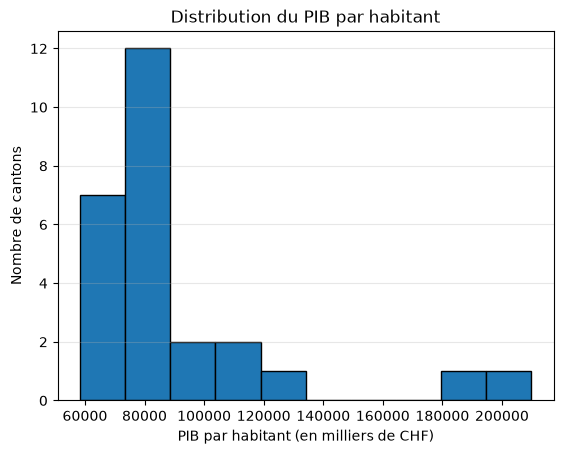

In [5]:
# Histogramme du PIB par habitant
plt.hist(cantons["pib_hab"], bins=10, edgecolor="black")

plt.xlabel("PIB par habitant (en milliers de CHF)")
plt.ylabel("Nombre de cantons")
plt.title("Distribution du PIB par habitant")

plt.grid(axis="y", alpha=0.3)

plt.show()

Nous pouvons avoir une bonne première visualisation du PIB/habitant par cantons en Suisse. On voit que la majorité se trouve autour de 80'000 CHF et que quelques exceptions se trouvent aux alentours de 200'000 CHF.

### 3. Analyse principale : $\text{densité } \leftrightarrow \text{ PIB/habitant}$

#### 3.1 Existe-t-il une relation positive entre densité de population et PIB par habitant ?

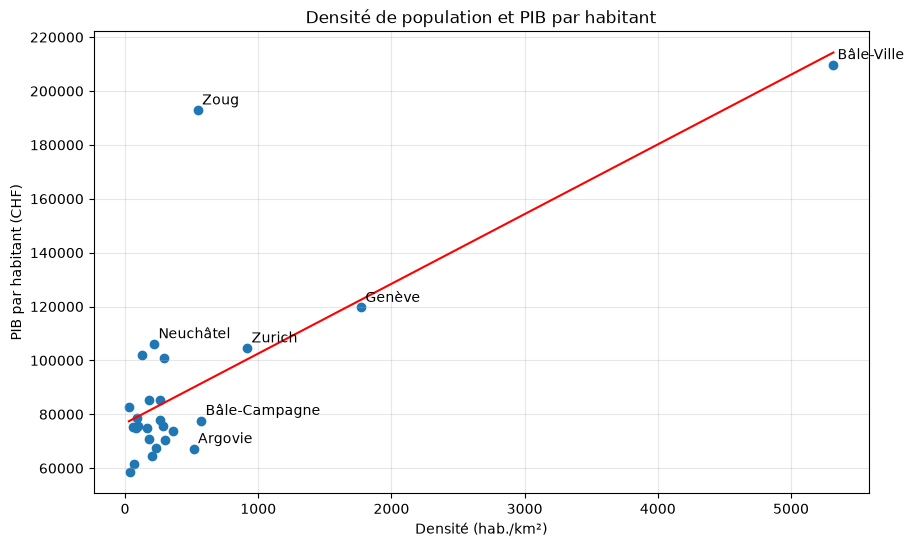

In [6]:
# Scatter plot pour la densité de population
plt.figure(figsize=(10,6))

# Regression linéaire entre la densité de population et le PIB par habitant
x = cantons["densite_km2"]
y = cantons["pib_hab"]

a, b = np.polyfit(x, y, 1) # Calcul des coefficients de la régression linéaire

x_regression = np.linspace(x.min(), x.max(), 100) # Création d'un vecteur de valeurs pour la densité de population
y_regression = a * x_regression + b # Calcul des valeurs correspondantes pour le PIB par habitant

plt.scatter(x, y)

plt.plot(
    x_regression,
    y_regression,
    color="red",
    label="Regression linéaire"
)

plt.title("Densité de population et PIB par habitant")
plt.xlabel("Densité (hab./km²)")
plt.ylabel("PIB par habitant (CHF)")

plt.grid(alpha=0.3)

for i, ligne in cantons.iterrows():
    if ligne["densite_km2"] > 400 or ligne["pib_hab"] > 105000:
        plt.annotate(
            ligne["canton"],
            (ligne["densite_km2"],ligne["pib_hab"]),
        xytext = (3,4),
        textcoords = "offset points"
        )

plt.show()

#### Première observation

A première vue, il semble y avoir une tendance positive entre densité et PIB par habitant mais il y a des valeurs comme Bâle-ville qui rendent le reste des données difficilement lisible.

#### 3.2 Scatter plot entre PIB par habitant et densité avec échelle logarithmique


In [7]:
# Trie des cantons par langue
romands=[
    "Vaud",
    "Genève",
    "Neuchâtel",
    "Jura",
    "Fribourg",
    "Valais"
]
tessin=["Tessin"]

cantons_romand=cantons[cantons["canton"].isin(romands)]
cantons_tessin=cantons[cantons["canton"].isin(tessin)]
cantons_allemand=cantons[~cantons["canton"].isin(romands+tessin)]

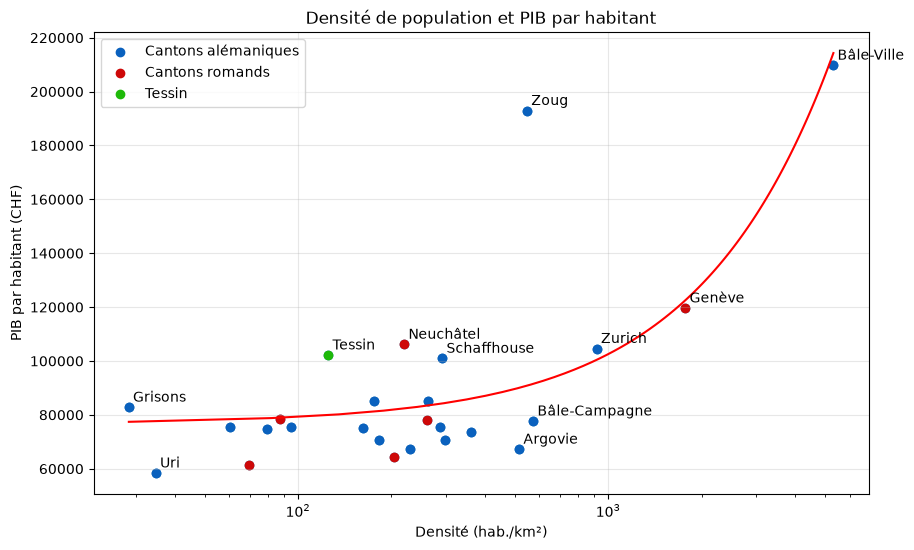

In [8]:
# Scatter plot avec échelle logarithmique pour la densité de population
plt.figure(figsize=(10,6))

plt.scatter(cantons["densite_km2"], cantons["pib_hab"])

plt.title("Densité de population et PIB par habitant")
plt.xlabel("Densité (hab./km²)")
plt.ylabel("PIB par habitant (CHF)")

# Ajout des scatter plots pour chaque groupe de cantons
plt.scatter(
    cantons_allemand["densite_km2"],
    cantons_allemand["pib_hab"],
    label="Cantons alémaniques",
    color="#0A61BE"
)

plt.scatter(
    cantons_romand["densite_km2"],
    cantons_romand["pib_hab"],
    label="Cantons romands",
    color="#CE0808"
)

plt.scatter(
    cantons_tessin["densite_km2"],
    cantons_tessin["pib_hab"],
    label="Tessin",
    color="#1EB909"
)

plt.legend()

plt.grid(alpha=0.3)

# Regression linéaire entre la densité de population et le PIB par habitant
x = cantons["densite_km2"]
y = cantons["pib_hab"]

a, b = np.polyfit(x, y, 1) # Calcul des coefficients de la régression linéaire

x_regression = np.linspace(x.min(), x.max(), 100) # Création d'un vecteur de valeurs pour la densité de population
y_regression = a * x_regression + b # Calcul des valeurs correspondantes pour le PIB par habitant

plt.plot(
    x_regression,
    y_regression,
    color="red",
    label="Regression linéaire"
)

plt.xscale("log")

for i, ligne in cantons.iterrows():
    if ligne["densite_km2"] > 400 or ligne["pib_hab"] > 100000 or ligne["densite_km2"] < 50:
        plt.annotate(
            ligne["canton"],
            (ligne["densite_km2"],ligne["pib_hab"]),
        xytext = (3,4),
        textcoords = "offset points"
        )

plt.show()

#### Deuxième observation

Sur ce graphique avec échelle logarithmique, on peut beaucoup mieux visualiser la répartition des cantons. On remarque aussi que la régression linéaire est courbée par cette échelle logarithmique.

### 3.3 Mesure de la force de la relation

#### Calcul de la corrélation
Après avoir la visualisation de la relation passons à la quantification en calculant la corrélation.

In [9]:
correlation = cantons["densite_km2"].corr(cantons["pib_hab"])

print(f"Coefficient de corrélation : {correlation:.3f}")

Coefficient de corrélation : 0.748


#### Calcul du $R^2$

In [10]:
r2 = correlation**2

print(f"R² = {r2:.3f}")

R² = 0.559


Dans cette régression simple, environ 56% de la variation observée du PIB par habitant est associée à la densité de population.

### 3.4 Analyse de sensibilité en retirant trois observations extrêmes

#### Observations extrêmes 

Certaines observations se distinguent fortement du reste des cantons. Si on met à part les deux cantons avec la plus grande densité et les deux cantons avec le PIB par habitant le plus haut. Il y a 3 cantons qui ressortent, $\textbf{Bâle-ville}$, $\textbf{Genève}$ et $\textbf{Zoug}$. Observons si en l'absence de ces trois cantons, la robustesse de la relation entre densité et PIB par habitant reste similaire.

In [11]:
# Enlever les outliers pour refaire la régression linéaire
df_sans_outliers = cantons[~cantons["canton"].isin(["Genève", "Zoug", "Bâle-Ville"])]

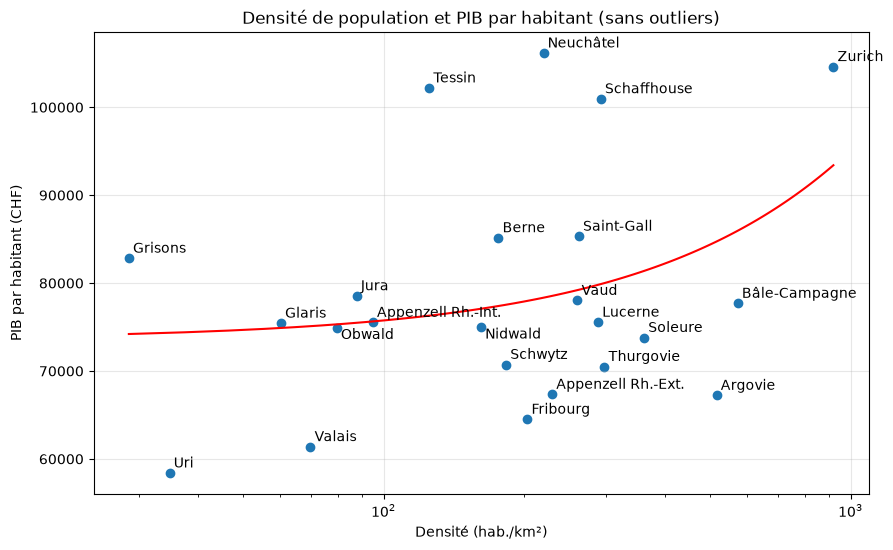

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_sans_outliers["densite_km2"], 
    df_sans_outliers["pib_hab"]
)

x2 = df_sans_outliers["densite_km2"]
y2 = df_sans_outliers["pib_hab"]

a2, b2 = np.polyfit(x2, y2, 1) # Calcul des coefficients de la régression linéaire

x_regression = np.linspace(x2.min(), x2.max(), 100) # Création d'un vecteur de valeurs pour la densité de population
y_regression = a2 * x_regression + b2 # Calcul des valeurs correspondantes pour le PIB par habitant

plt.plot(
    x_regression,
    y_regression,
    color="red",
    label="Regression linéaire"
)

plt.xscale("log")

plt.xlabel("Densité (hab./km²)")
plt.ylabel("PIB par habitant (CHF)")
plt.title("Densité de population et PIB par habitant (sans outliers)")

plt.grid(alpha=0.3)

for i, ligne in cantons.iterrows():
    if ligne["canton"] == "Obwald" or ligne["canton"] == "Nidwald":
        plt.annotate(
            ligne["canton"],
            (ligne["densite_km2"],ligne["pib_hab"]),
            xytext = (3,-8),
            textcoords = "offset points"
            )
    else:
        plt.annotate(
            ligne["canton"],
            (ligne["densite_km2"],ligne["pib_hab"]), 
        xytext = (3,4),
        textcoords = "offset points"
    )

plt.show()

Voilà ce que donne le scatter plot sans les "valeurs atypiques" que j'ai choisies. La tendance paraît beaucoup moins claire. Observons maintenant la corrélation de ce set de données sans "Zoug", "Genève" et "Bâle-ville".

#### 3.4.2 La relation entre densité et PIB/habitant est-elle robuste à la présence de quelques observations extrêmes ?

##### Calcul de corrélation

In [13]:
correlation_sans_outliers = df_sans_outliers["densite_km2"].corr(df_sans_outliers["pib_hab"])

print(f"Coefficient de corrélation avec tous les cantons : {correlation:.3f}")
print(f"Coefficient de corrélation sans outliers : {correlation_sans_outliers:.3f}")

Coefficient de corrélation avec tous les cantons : 0.748
Coefficient de corrélation sans outliers : 0.328


##### Calcul du $R^2$

In [14]:
r2_sans_outliers = correlation_sans_outliers ** 2

print(f"R² avec tous les cantons : {r2:.3f}")
print(f"R² sans les valeurs atypiques : {r2_sans_outliers:.3f}")

R² avec tous les cantons : 0.559
R² sans les valeurs atypiques : 0.108


Avec l'ensemble des cantons, le modèle explique environ 55,9% de la variation du PIB par habitant. Après exclusion de Bâle-ville, Zoug et Genève, le $R^2$ tombe à environ 10,8%.

#### 3.5 Comparaison des modèles

| Modèle | Corrélation | R² |
|---|---:|---:|
| Tous les cantons | 0.748 | 0.559 |
| Sans Bâle-Ville, Zoug et Genève | 0.328 | 0.108 |

Après avoir comparé la robustesse de la relation avec et sans les valeurs extrêmes. On peut constater que la relation densité et PIB par habitant est fortement influencée par quelques observations extrêmes.

#### 3.6 Limites de l'analyse

Cette analyse présente plusieurs limites. Premièrement, l'échantillon ne comprend que 26 observations, correspondant aux cantons suisses. Les résultats peuvent donc être fortement influencés par quelques observations particulières.

Deuxièmement, la régression utilisée est une régression linéaire simple. Elle ne prend en compte que la densité de population pour expliquer les différences de PIB par habitant. D'autres facteurs économiques peuvent également influencer le PIB par habitant et être corrélés avec la densité.

Enfin, les résultats doivent être interprétés comme une première analyse descriptive et économétrique. Ils ne doivent pas être considérés comme une estimation d'un effet causal de la densité sur le PIB par habitant.

#### 3.7 Conclusion générale

Ce projet avait pour objectif d'explorer les différences entre les cantons suisses et d'étudier la relation entre la densité de population et le PIB par habitant. Il m'a également permis de réaliser un projet concret d'analyse de données, depuis la recherche et la collecte des données jusqu'à leur nettoyage, leur traitement et leur analyse à l'aide de Python.

Les statistiques descriptives montrent des différences importantes entre les cantons. L'analyse graphique et la régression linéaire mettent ensuite en évidence une association positive entre les deux variables. Toutefois, cette relation est fortement influencée par quelques cantons présentant des caractéristiques atypiques.

Cette première analyse permet ainsi de mettre en évidence une relation statistique, tout en soulignant l'importance des valeurs atypiques et les limites de cette analyse.